# Mathematical modeling of brain tumor grow on 2D
### Emma Kuutti 101659787


<a id="table"></a>
## Table of Contents

1. Introduction
2. Theory
   1. Brain tumors - Types and spreading
   2. The Fisher-KPP equation
   3. Constants -Getting and using them
   
3. Codes and calculations
   1. Importing needed libaries
   2. Getting diffusion map
   3. Initiliaze seed tumor
   4. Predict the growth
   5. The Impact of parameters
4. Result and analysis
   1. The impact of initial position of tumor
   2. The impact of parameters
   3. Realiably and robustness
   4. Efficiency and feasibility
   
5. Summary

Reference

## 1. Introduction
Brain tumors represent one of the most significant challenges in modern oncology due to their aggressive nature and the critical complexity of the organ they inhabit. The progression and infiltration of these tumors are not uniform. It is a complex phenomenon depending on the tumor's nature, position in the brain, as well as patients' brain anatomy. If one could predict the spreading, it could help with personalized treatment plans and thus help make treatment more efficient. [1,2]

In this project, the spreading of the brain tumor is modelled using the Fischer-KPP equation, which is a reaction-diffusion model combining linear diffusion with logistic growth [3]. The linear diffusion represents the random mobility of cancer cells as they infiltrate outward into healthy brain tissue. The logistic growth represents the proliferation of the cells. The impact of the initial position of the tumor and parameters in the equation for spreading is studied with the tumor growth simulation for 30 days.

The structure of the project is as follows: First, the theory of brain tumor types and spreading, then a little bit about the Fischer-KPP equation, as well as the datasets and constants. Then there is the code part, where first is a simulation with one set of parameters to get the impact of the initial position of the tumor, and after a comparison of different parameter values. Finally, an analysis of the results, summary, and references.




<a id="theory"></a>
## 2. Theory
<a id="tumors"></a>
### Brain tumors -Types and spreading
Understanding tumor growth in the brain is a crucial but very complex challenge. Brain tumors are cells that become abnormal and start to grow in the way they should not. The growths of different tumors can be categorized as bening or malignant. Bening tumors are non-cancerous and typically grow with slower rates than cancerous malignant brain tumors, which can be very aggressive and even spread to other regions of the central nervous system. Despite of bening tumors' non-cancerous nature, they can still cause health issues, for example by causing pressure to other brain structures. [1,2] 

The world health organization WHO divides tumors into 4 grades. Grade 1 tumors are benign tumors that spread extremely slowly and can stay stable for years. In MRI scans they usually have very clear borders, because they practically do not diffuse or move with spreading typically being 0 mm to 2 mm per year. Grade 2 tumors are low-grade tumors, sometimes called infiltrative tumors, that diffuse and spread on average 4 mm per year. They also have a high tendency to transform into higher grades. Grade 3 tumors are malignant tumors with fast spreading, typically spreading 10 to 15 mm per year. Grade 4 tumors are very aggressive and can grow their own blood vessels to feed rapid expansion. Grade 4 tumors can spread between 30 to over 50 mm per year. [4, 5, 6] 

Due to the nature of brain tumor growth, it is often characterized by diffusion. The diffusion coefficients are different for the white and grey matter in the brain. In simulations the white matter diffusion coefficient is roughly five times bigger than in grey matter. The difference in the coefficients is caused by tumors faster spreading in the white matter. [7]


<a id="kpp"></a>
### The Fisher-KPP equation
The Fisher-KPP equation is the partial differential equation that models a reaction-diffusion model combining the linear diffusion with logistic growth. [3]


In this case we will use this form of the Fisher-KPP equation:
$$
\begin{equation}
\frac{du}{dt}=\nabla \cdot (D\nabla u) + \rho u (1-u)
\end{equation}
$$

where $u$ is tumor cell density, $D$ is the diffusion tensor and $\rho$ is the proliferation rate. [3] The diffusion tensor tells the borders of grey and white matter as well as bone and how fast the tumor can spread in each area. The proliferation rate practically tells how fast the tumor spreads. In reality it depends on the type of tumor and the stage of tumor spreading, as some types of tumors have agressive and non-agressive stages. [4]


<a id="usingdata"></a>
### Constant - Getting and using them
To get the initial diffusion map, one brain slice image from [8] was used to get a map of grey and white matter areas in the brain. To get other needed constants the article [7] typical values of diffusion constants and the proliferation rate was used as well as the standard relationship between white and grey matter diffusion constants [7].



<a id="code"></a>
## 3. Codes and calculations

### Importing needed libaries

In [1]:
# import needed libaries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from IPython import display
import time

<a id="values"></a>
### Getting diffusion map
The diffusion map is obtained using a MRI brain scan from [8] and mapping of the white and gray matter is done based on the brightness of the image. 

In [3]:
#Loading the 2D brain slice and get a array
img=Image.open('brain_slice.jpg').convert('L')
brain_map=np.array(img)

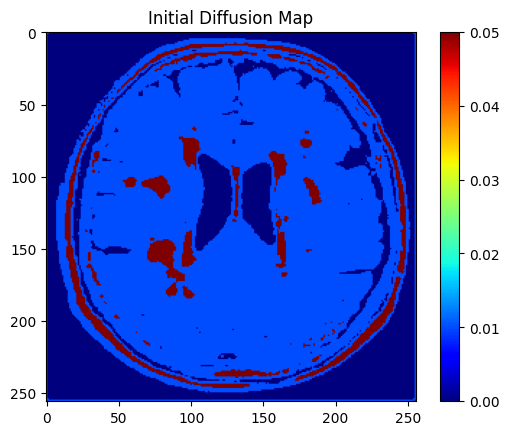

In [ ]:
#Define diffusion constants and make a map based on image (Grey and white matter)

#Ratio 5:1 is standard LÄHDE Swanson
Dw = 0.05  # White matter diffusion mm^2/day
Dg = 1/5*Dw  # Grey matter diffusion mm^2/day
rho = 0.02 # Proliferation rate per day

#Diffusion matrix
D = np.zeros_like(brain_map, dtype=float)
D[brain_map > 200] = Dw      # High intensity = White matter
D[(brain_map <= 200) & (brain_map > 50)] = Dg  # Mid intensity = Grey matter
D[brain_map <= 50] = 0       # Dark = CSF/Bone/Background 

# Visualization of the Map
plt.imshow(D, cmap='jet')
plt.title("Initial Diffusion Map")
plt.colorbar()
plt.show()

<a id="init"></a>
### Initialize tumor
The tumor is initialized randomly inside of the brain.

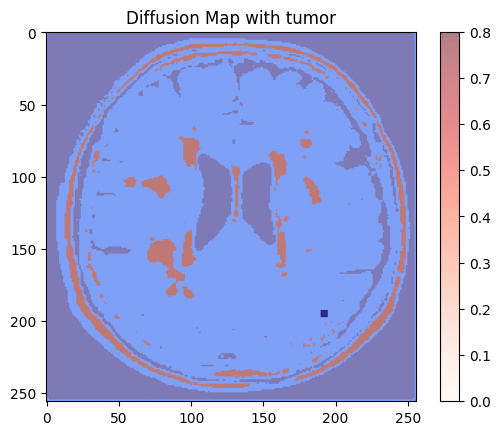

In [ ]:
#Initialize Tumor
tumor = np.zeros_like(brain_map, dtype=float)
# Seed a small tumor in the random position, but in the area where diffusion is not zero

found_spot = False
while not found_spot:
    rx, ry = np.random.randint(0, 256, size=2)
    if D[rx, ry] > 0: # Check if it's inside the brain tissue
        # Create a small 5x5 circle of cells
        tumor[rx-2:rx+3, ry-2:ry+3] = 0.8 
        found_spot = True

#then visualize placed tumor

plt.imshow(D, cmap='jet')
plt.imshow(tumor, cmap='Reds', alpha=0.5)
plt.title("Diffusion Map with tumor")
plt.colorbar()
plt.show()        

### Predicting the growth
The simulation runs always 30 days at the time. One ought to run the simulation a couple of times to see more growth and influence of the diffusion map. If you want to see how the initial position of the seed tumor impacts growth, restart the kernel and run the simulation with a different position.

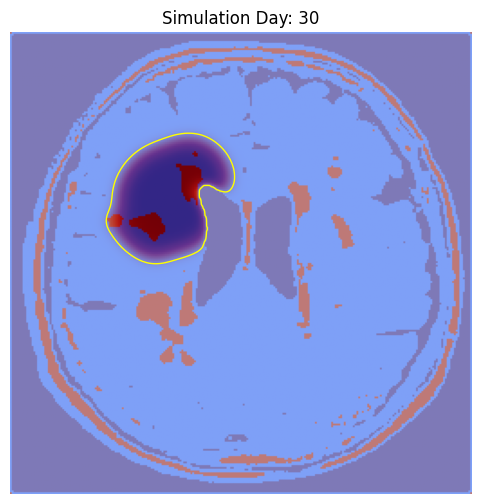

In [59]:



fig, ax = plt.subplots(figsize=(6, 6))
# Parameters
dt = 0.1      # Time step 
dx = 1.0      # Space step (pixel width)
rho = 0.02    # Proliferation rate
steps = 500   # Total iterations

for day in range(1, 31):
    # Run math for one day
    for _ in range(50):
        # Laplacian calculation 
        #u_lap = (np.roll(tumor, -1, 0) + np.roll(tumor, 1, 0) + np.roll(tumor, -1, 1) + np.roll(tumor, 1, 1) - 4*tumor)
        u_lap = np.zeros_like(tumor)
        u_lap[1:-1, 1:-1] = (
            tumor[:-2, 1:-1] + tumor[2:, 1:-1] +  # Top and Bottom
            tumor[1:-1, :-2] + tumor[1:-1, 2:] -  # Left and Right
            4 * tumor[1:-1, 1:-1]                 # Center
        )
        tumor += dt * (D * u_lap + rho * tumor * (1 - tumor))
        tumor = np.clip(tumor, 0, 1)

    # Visualization
    ax.clear()
    ax.imshow(D, cmap='jet')
    ax.imshow(tumor, cmap='Reds', alpha=0.5)
    ax.contour(tumor, levels=[0.2], colors='yellow', linewidths=1)
    ax.set_title(f"Simulation Day: {day}")
    ax.axis('off')

    
    display.clear_output(wait=True)
    display.display(fig)
    time.sleep(0.05) # Adjust speed of animation

plt.close()

### The impact of the parameters

The used parameters affect the results. Next we will compare 30-days of tumor growth with parameters in the range of 0.01 to 0.1 for $\rho$ and 0.01 to 0.2 for white matter diffusion coefficient. The code shows the simulation with each pair of parameters and at the end a grid with 30-day results for easy comparison. For comparison with real cases the average velocities in white and grey matter for every pair of parameters was calculated like in [4].

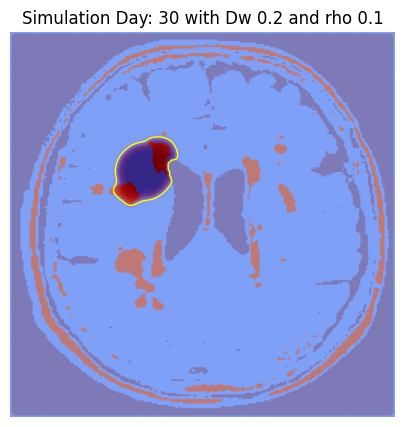

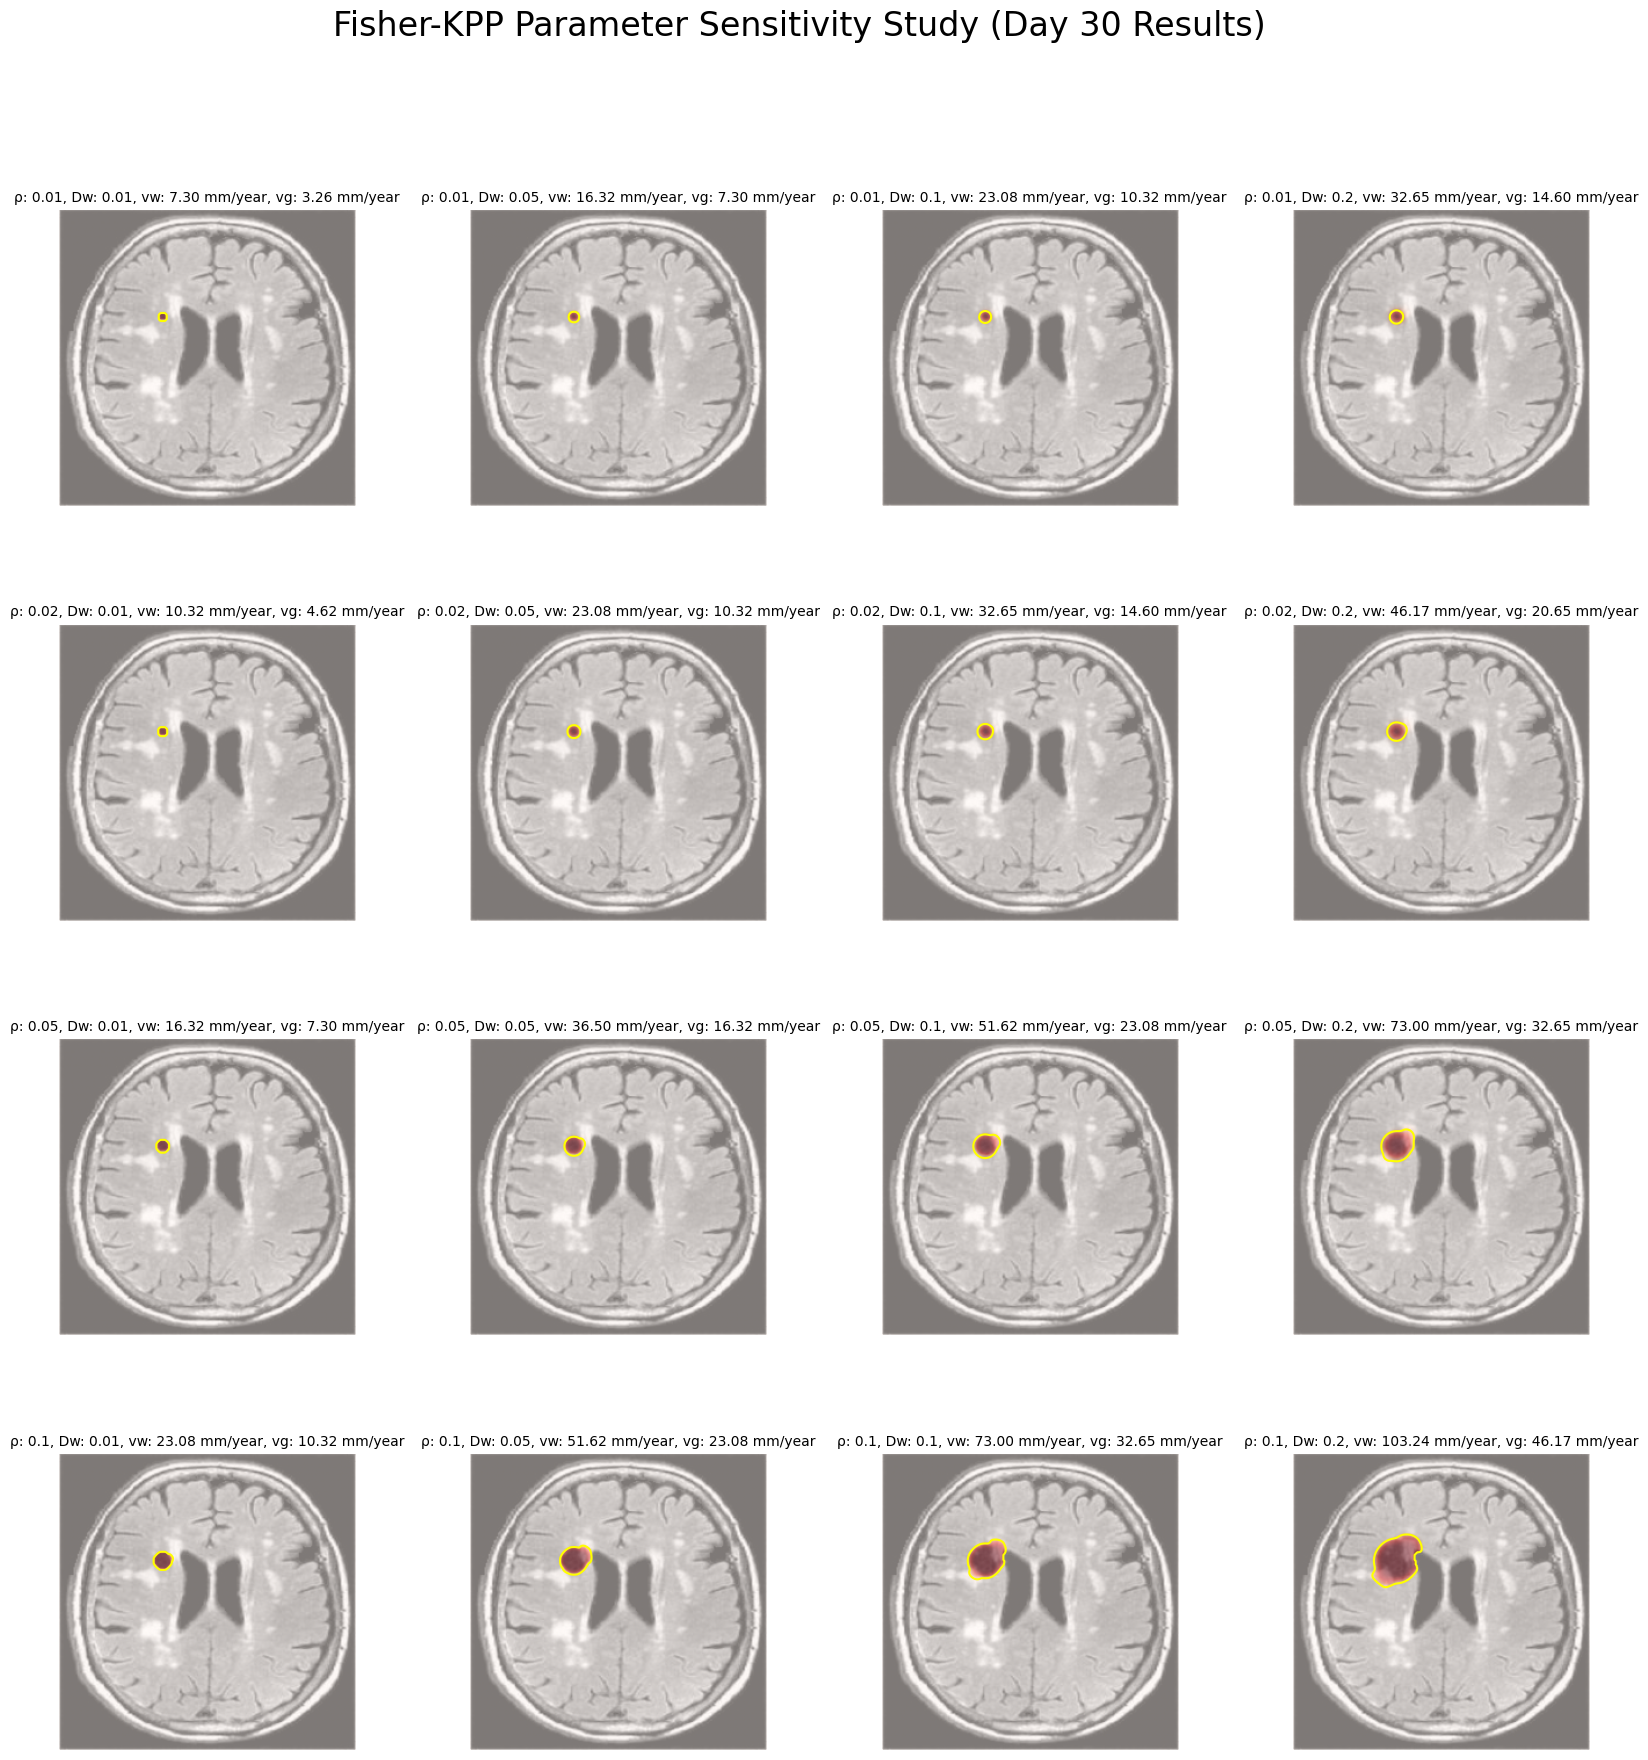

In [57]:
rho_range = [0.01, 0.02, 0.05, 0.1]
dw_range = [0.01, 0.05, 0.1, 0.2]

tumorPlaced = False

fig, axes = plt.subplots(len(rho_range), len(dw_range), figsize=(20, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i,rho in enumerate(rho_range):
    for j,dw in enumerate(dw_range):
        #Diffusion matrix
        Dg=1/5*dw
        D = np.zeros_like(brain_map, dtype=float)
        D[brain_map > 200] = dw      # High intensity = White matter
        D[(brain_map <= 200) & (brain_map > 50)] = Dg  # Mid intensity = Grey matter
        D[brain_map <= 50] = 0       # Dark = CSF/Bone/Background 

        #Velocity calculations
        vw=2 * np.sqrt(dw * rho ) * 365
        vg=2 * np. sqrt( Dg * rho) * 365
        # Visualization of the Map
        #plt.imshow(D, cmap='jet')
        #plt.title(f"Initial Diffusion Map when Dw={dw}")
        #plt.colorbar()
        #plt.show()

        #Set a tumor (same place for all that comparison is easier)
        
        while tumorPlaced== False:
            #Initialize Tumor
            # Seed a small tumor in the random position, but in the area where diffusion is not zero

            found_spot = False
            while not found_spot:
                rx, ry = np.random.randint(0, 256, size=2)
                if D[rx, ry] > 0: # Check if it's inside the brain tissue
                    # Create a small 5x5 circle of cells
                    found_spot = True
                    tumorPlaced = True
        
        #Start new tumor in same position
        tumor = np.zeros_like(brain_map, dtype=float)
        tumor[rx-2:rx+3, ry-2:ry+3] = 0.8

        # Grow and plot
        
        # Parameters
        dt = 0.1      # Time step 
        dx = 1.0      # Space step (pixel width)
        
        steps = 500   # Total iterations
        fig_anim, ax_anim = plt.subplots(figsize=(5, 5)) #for animation
        for day in range(1, 31):
            # Run math for one day
            for _ in range(50):
                # Laplacian calculation 
                #u_lap = (np.roll(tumor, -1, 0) + np.roll(tumor, 1, 0) + np.roll(tumor, -1, 1) + np.roll(tumor, 1, 1) - 4*tumor)
                u_lap = np.zeros_like(tumor)
                u_lap[1:-1, 1:-1] = (
                    tumor[:-2, 1:-1] + tumor[2:, 1:-1] +  # Top and Bottom
                    tumor[1:-1, :-2] + tumor[1:-1, 2:] -  # Left and Right
                    4 * tumor[1:-1, 1:-1]                 # Center
                )
                tumor += dt * (D * u_lap + rho * tumor * (1 - tumor))
                tumor = np.clip(tumor, 0, 1)

            # Visualization
            ax_anim.clear()
            ax_anim.imshow(D, cmap='jet')
            ax_anim.imshow(tumor, cmap='Reds', alpha=0.5)
            ax_anim.contour(tumor, levels=[0.2], colors='yellow', linewidths=1)
            ax_anim.set_title(f"Simulation Day: {day} with Dw {dw} and rho {rho}")
            ax_anim.axis('off')

            
            display.clear_output(wait=True)
            display.display(fig_anim)

        #time.sleep(0.05) # Adjust speed of animation
        ax = axes[i, j]
        ax.imshow(brain_map, cmap='gray') # Background brain
        ax.imshow(tumor, cmap='Reds', alpha=0.5) # Tumor overlay
        ax.contour(tumor, levels=[0.2], colors='yellow', linewidths=1.5)
        
        ax.set_title(f"ρ: {rho}, Dw: {dw}, vw: {vw:.2f} mm/year, vg: {vg:.2f} mm/year", fontsize=10)
        ax.axis('off')
        plt.close()

plt.suptitle("Fisher-KPP Parameter Sensitivity Study (Day 30 Results)", fontsize=24)
plt.show()

        
    

## 4. Results and analysis


### The impact of initial position of tumor
By running the first parts of the code several times, one sees how the initial position of tumor impacts its growth in the future. The most noticeable difference is gotten when the tumor is placed in high diffusion areas, e.g. in white matter, that acts as a highway for the tumor to spread. In that case the tumor starts spreading much faster than in the case where it started in the grey matter. If the tumor is placed near zero diffusion areas, such as near the bone, the spreading is slower because tumor cannot spread into it.


### The impact of parameters
The impact of proliferation rate and diffusion coefficients were studied by plotting the 30-day result of different parameters in the grid, where on rows the proliferation coefficient stays constant and on the columns diffusion coefficients stay constant. The minimum and maximum growth is easily spotted in the grid as they are the cases where both parameters are at their minimum or maximum (top left, bottom right). Each row shows that increasing the diffusion coefficients results in bigger tumor. The columns show the same effect for proliferation rate.  

The parameter pairs can also be divided by WHO grades. The tumor is mostly in grey matter as the brain mostly consists of it, so the grey matter velocity is dominant when comparing. The impact of white matter changes depending on the tumor's position. The visualization of WHO grades for parameter pairs is shown in figure 1.


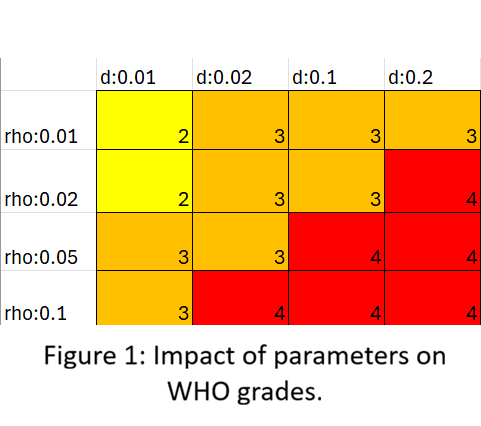

### Reliably and robustness 

Although the model works, it is still a model and in real cases there are many individual parameters that impact tumor growth. Also, the model works in 2D, but in real life tumors grow in 3D which causes errors in the simulation.

The strict comparison with real clinical cases is nearly impossible because of the variety of tumors and patients. By WHO grades the results seem to be realistic. Different parameter pairs correspond to different grades at WHO's scale and velocities stay at a realistic scale. Also, the effect of the high diffusion areas is clearly seen in simulation, so the implementation is working. 

The model could be used for specialized treatment, of course if first validated and further developed for 3D. The diffusion coefficient could be obtained for a patient with an MRI scan [9] and the proliferation rate could be obtained with PET monitoring [10]. The model could be used for example to see if chemotherapy is working by comparing the simulated growth without chemo and the real growth after chemo.



### Efficiency and feasibility

In big O notation the efficiency for a single animation, such as in the initial position code, is O(n^2). It stays the same also in the comparison code but due to iterations the number of operations increases. Our diffusion map is 256x256 pixels and for single animation the code does 30x50 iterations for those 256^2 pixels, making the total number of operations about 100 million. For the comparison, the code does that 16 times so there are about 1.6 billion operations.

Due to large number of pixels in problems related to medical images and models, there are typically a large number of operations. The complexity of O(n^2) is good and typical for image related problems. The slowest part of the code is plotting. By leaving the animation out and plotting only the 30-day results, the run time of code would be much smaller. Although, the animation of the growth is nice a visualization and makes it easier to investigate the impact of initial position of the tumor. 

With the current resolution and use of NumPy vectorized operations, the code is feasible. If one were to double the resolution, the run time would be four times slower. Also, if one were to develop this to 3D for more realistic prediction, the efficiency would increase to O(n^3). Also, due to number of pixels (256^3), the code would occupy lot of memory during run time which probably would become problem with scaling.



## 5. Summary 


Brain tumors are a complex problem and predicting spreading depends on the type of tumor as well as individual parameters of a patient which makes the treatment planning complicated. Brain tumors are classified in four grades by WHO. Tumor spreading depends simplified on tumor type, initial position and ratio of white and grey matter in the brain. The tumor's spread can be modeled with diffusion. The white matter works like a highway for tumors and allows faster spreading than in the grey matter.

In this project brain tumor growth was simulated using the Fischer-KPP equation that is a reaction-diffusion model, taking into account the diffusion type of tumor as well as the type of tumor. With the used resolution, 2D model and NumPy operations, the simulation was feasible and in range of typical efficiency O(n^2) for this kind of problem.

The impact of initial tumor position, profeliration rate and diffusion coefficients were studied. The parameter pairs were classified by WHO grading for tumor spreading. Tested parameters correspond to grades 2, 3 and 4 and the initial position impacts the grade by determining how fast the tumor enters the high diffusion area. The most errors in the result were caused by simplifying 3D tumor growth into a 2D model, thus the model is not completely realistic, although works relatively well.

If the model were to be developed in 3D and validated with a dataset consisting of different grade tumors, it could be used to predict growth and for example comparing chemotherapy results to simulated growth rates to see if the treatment works.





## References

[1] J. R. McFaline-Figueroa and E. Q. Lee, “Brain Tumors,” Am. J. Med., vol. 131, no. 8, pp. 874–882, Aug. 2018, doi: 10.1016/J.AMJMED.2017.12.039.


[2]Harshad Sakariya, Ravi Shankar Prasad, Sushil Kumar, “A study on brain tumor dynamics in two-dimensional irregular domain with variable-order time-fractional derivative”, Computer Methods and Programs in Biomedicine, Volume 264, 2025, 108700, ISSN 0169-2607, https://doi.org/10.1016/j.cmpb.2025.108700.

[3] M. Fritz and N. I. Kavallaris, “A TIME-FRACTIONAL FISHER-KPP EQUATION FOR TUMOR GROWTH: ANALYSIS AND NUMERICAL SIMULATION.”

[4]Mandonnet E, Delattre JY, Tanguy ML, Swanson KR, Carpentier AF, Duffau H, Cornu P, Van Effenterre R, Alvord EC Jr, Capelle L. Continuous growth of mean tumor diameter in a subset of grade II gliomas. Ann Neurol. 2003 Apr;53(4):524-8. doi: 10.1002/ana.10528. PMID: 12666121.

[5]. Stensjøen AL, Solheim O, Kvistad KA, Håberg AK, Salvesen Ø, Berntsen EM. Growth dynamics of untreated glioblastomas in vivo. Neuro Oncol. 2015 Oct;17(10):1402-11. doi: 10.1093/neuonc/nov029. Epub 2015 Mar 10. PMID: 25758748; PMCID: PMC4578579.

[6]. International Agency for Research on Cancer, "Central Nervous System Tumours," WHO Classification of Tumours Online, 5th ed., vol. 6. [Online]. Saatavilla: https://tumourclassification.iarc.who.int.

[7] K. R. Swanson, J. Alvord, and J. D. Murray, “A quantitative model for differential motility of gliomas in grey and white matter,” Cell Prolif., vol. 33, no. 5, pp. 317–329, 2000, doi: 10.1046/j.1365-2184.2000.00177.x.
 
[8] ThomasDubail, “Brain tumors 256×256: A refined brain tumor image dataset with grayscale normalization and zoom,” Kaggle, 2023. [Online]. Available: https://www.kaggle.com/datasets/thomasdubail/brain-tumors-256x256. [Accessed: Mar. 3, 2026].


[9]K. R. Swanson, C. Bridge, J. D. Murray, and E. C. Alvord Jr, "Virtual brain tumours (gliomas) enhance the reality of medical imaging and highlight inadequacies of current therapy," Br. J. Cancer, vol. 86, no. 1, pp. 14–18, Jan. 2002, doi: 10.1038/sj.bjc.6600021.

[10]K. Van Heertum and B. Aubert, "Positron emission tomography imaging of cell proliferation," Methods, vol. 70, no. 1, pp. 24–30, Nov. 2014, doi: 10.1016/j.ymeth.2014.08.010
